In [2]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [3]:
df = pd.DataFrame()

In [4]:
df['X1'] = [1,2,3,4,5,6,6,7,7,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [5]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,7,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

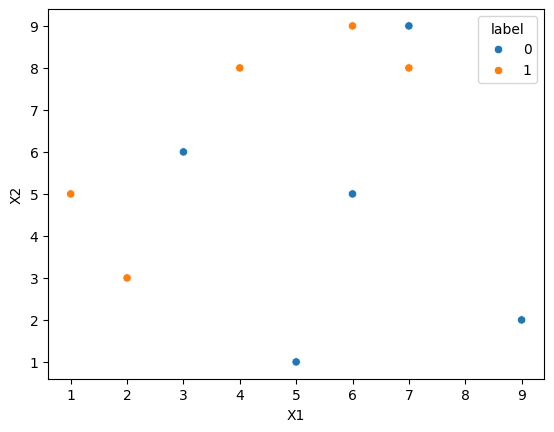

In [6]:
import seaborn as sns

sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [8]:
df['weights'] = 1/df.shape[0]

In [9]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,7,9,0,0.1
9,9,2,0,0.1


In [10]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [15]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [16]:
dt1.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

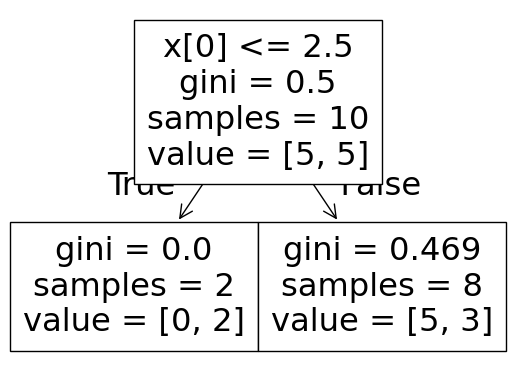

In [17]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

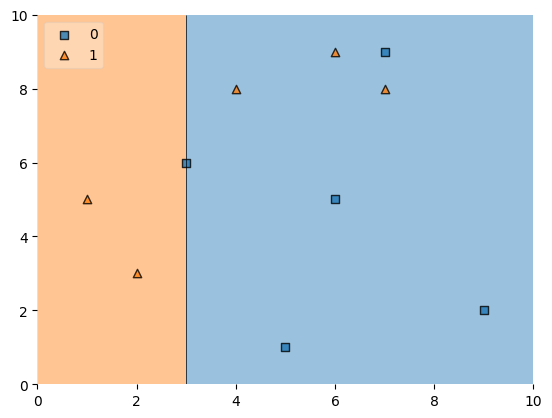

In [18]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [19]:
df['y_pred'] = dt1.predict(X)

In [20]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,7,9,0,0.1,0
9,9,2,0,0.1,0


In [21]:
def cal_model_wt(error):
    return 0.5 * np.log((1 - error) / (error))

In [22]:
alpha1 = cal_model_wt(0.3)
alpha1

0.42364893019360184

In [23]:
def update_row_wts(row, alpha=0.4236):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [24]:
df['updated_weights'] = df.apply(update_row_wts, axis=1) 

In [25]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065469
1,2,3,1,0.1,1,0.065469
2,3,6,0,0.1,0,0.065469
3,4,8,1,0.1,0,0.152745
4,5,1,0,0.1,0,0.065469
5,6,9,1,0.1,0,0.152745
6,6,5,0,0.1,0,0.065469
7,7,8,1,0.1,0,0.152745
8,7,9,0,0.1,0,0.065469
9,9,2,0,0.1,0,0.065469


In [26]:
df['updated_weights'].sum()

0.9165151400883117

In [27]:
df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()

In [28]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065469,0.071432
1,2,3,1,0.1,1,0.065469,0.071432
2,3,6,0,0.1,0,0.065469,0.071432
3,4,8,1,0.1,0,0.152745,0.166659
4,5,1,0,0.1,0,0.065469,0.071432
5,6,9,1,0.1,0,0.152745,0.166659
6,6,5,0,0.1,0,0.065469,0.071432
7,7,8,1,0.1,0,0.152745,0.166659
8,7,9,0,0.1,0,0.065469,0.071432
9,9,2,0,0.1,0,0.065469,0.071432


In [30]:
df['normalized_weights'].sum()

1.0

In [31]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']


In [32]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065469,0.071432,0.071432,0.000000
1,2,3,1,0.1,1,0.065469,0.071432,0.142864,0.071432
2,3,6,0,0.1,0,0.065469,0.071432,0.214296,0.142864
3,4,8,1,0.1,0,0.152745,0.166659,0.380955,0.214296
4,5,1,0,0.1,0,0.065469,0.071432,0.452387,0.380955
5,6,9,1,0.1,0,0.152745,0.166659,0.619045,0.452387
6,6,5,0,0.1,0,0.065469,0.071432,0.690477,0.619045
7,7,8,1,0.1,0,0.152745,0.166659,0.857136,0.690477
8,7,9,0,0.1,0,0.065469,0.071432,0.928568,0.857136
9,9,2,0,0.1,0,0.065469,0.071432,1.000000,0.928568


In [34]:
df[['X1','X2','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,0.1,1,0.065469,0.000000,0.071432
1,2,3,0.1,1,0.065469,0.071432,0.142864
2,3,6,0.1,0,0.065469,0.142864,0.214296
3,4,8,0.1,0,0.152745,0.214296,0.380955
4,5,1,0.1,0,0.065469,0.380955,0.452387
5,6,9,0.1,0,0.152745,0.452387,0.619045
6,6,5,0.1,0,0.065469,0.619045,0.690477
7,7,8,0.1,0,0.152745,0.690477,0.857136
8,7,9,0.1,0,0.065469,0.857136,0.928568
9,9,2,0.1,0,0.065469,0.928568,1.000000


In [39]:
def create_new_dataset(df):
    
    indices =[]
    
    for i in range(df.shape[0]):
        a = np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_lower']<a<row['cumsum_upper']:
                indices.append(index)
    return indices

In [40]:
index_values = create_new_dataset(df)
index_values

[9, 8, 4, 5, 5, 3, 5, 5, 0, 4]

In [41]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [42]:
second_df

,X1,X2,label,weights
9,9,2,0,0.1
8,7,9,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
4,5,1,0,0.1


In [43]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [44]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [45]:
dt2.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 3.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.625, 0.5, '  False')]

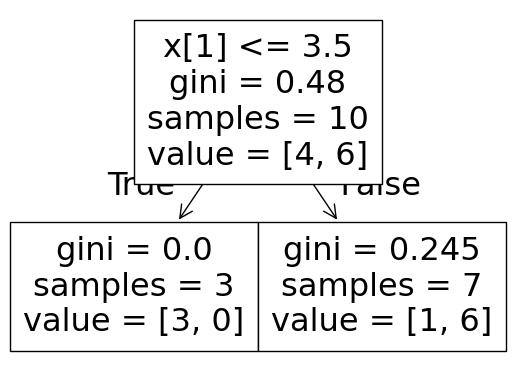

In [46]:
plot_tree(dt2)

<Axes: >

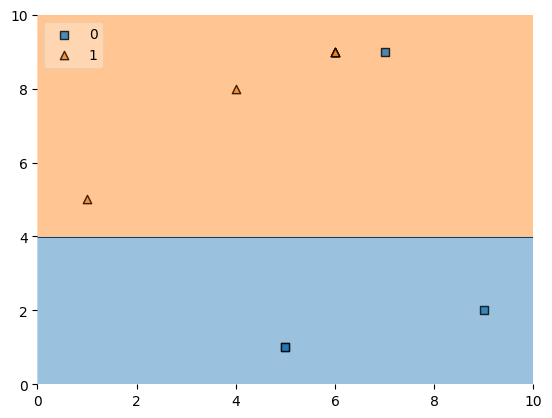

In [47]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [48]:
second_df['y_pred'] = dt2.predict(X)

In [49]:
second_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
8,7,9,0,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
5,6,9,1,0.1,1
3,4,8,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
0,1,5,1,0.1,1
4,5,1,0,0.1,0


In [50]:
alpha2 = cal_model_wt(0.1)
alpha2

1.0986122886681098

In [51]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [52]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [53]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
9,9,2,0,0.1,0,0.033622
8,7,9,0,0.1,1,0.297427
4,5,1,0,0.1,0,0.033622
5,6,9,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622
3,4,8,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622
0,1,5,1,0.1,1,0.033622
4,5,1,0,0.1,0,0.033622


In [54]:
second_df['updated_weights'].sum()

0.6000222515923667

In [55]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [56]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
9,9,2,0,0.1,0,0.033622,0.056034
8,7,9,0,0.1,1,0.297427,0.495694
4,5,1,0,0.1,0,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034


In [57]:
second_df['nomalized_weights'].sum()

0.9999999999999999

In [58]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [59]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [60]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights,cumsum_upper,cumsum_lower
9,9,2,0,0.1,0,0.033622,0.056034,0.056034,0.000000
8,7,9,0,0.1,1,0.297427,0.495694,0.551728,0.056034
4,5,1,0,0.1,0,0.033622,0.056034,0.607762,0.551728
5,6,9,1,0.1,1,0.033622,0.056034,0.663796,0.607762
5,6,9,1,0.1,1,0.033622,0.056034,0.719830,0.663796
3,4,8,1,0.1,1,0.033622,0.056034,0.775864,0.719830
5,6,9,1,0.1,1,0.033622,0.056034,0.831898,0.775864
5,6,9,1,0.1,1,0.033622,0.056034,0.887932,0.831898
0,1,5,1,0.1,1,0.033622,0.056034,0.943966,0.887932
4,5,1,0,0.1,0,0.033622,0.056034,1.000000,0.943966


In [61]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
9,9,2,0,0.1,0,0.056034,0.000000,0.056034
8,7,9,0,0.1,1,0.495694,0.056034,0.551728
4,5,1,0,0.1,0,0.056034,0.551728,0.607762
5,6,9,1,0.1,1,0.056034,0.607762,0.663796
5,6,9,1,0.1,1,0.056034,0.663796,0.719830
3,4,8,1,0.1,1,0.056034,0.719830,0.775864
5,6,9,1,0.1,1,0.056034,0.775864,0.831898
5,6,9,1,0.1,1,0.056034,0.831898,0.887932
0,1,5,1,0.1,1,0.056034,0.887932,0.943966
4,5,1,0,0.1,0,0.056034,0.943966,1.000000


In [62]:

index_values = create_new_dataset(second_df)

In [63]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [64]:
third_df

,X1,X2,label,weights
5,6,9,1,0.1
3,4,8,1,0.1
4,5,1,0,0.1
0,1,5,1,0.1
4,5,1,0,0.1
3,4,8,1,0.1
0,1,5,1,0.1
0,1,5,1,0.1
3,4,8,1,0.1
0,1,5,1,0.1


In [65]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: >

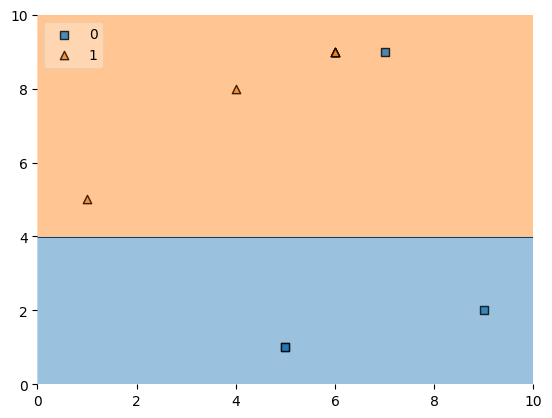

In [66]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [67]:
third_df['y_pred'] = dt3.predict(X)

In [68]:
third_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,0
3,4,8,1,0.1,1
4,5,1,0,0.1,0
0,1,5,1,0.1,1
4,5,1,0,0.1,1
3,4,8,1,0.1,1
0,1,5,1,0.1,1
0,1,5,1,0.1,1
3,4,8,1,0.1,1
0,1,5,1,0.1,0


In [70]:
alpha3 = cal_model_wt(0.2)
alpha3

0.6931471805599453

In [71]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 0.6931471805599453


# Prediction

In [72]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [73]:
dt2.predict(query)

array([1])

In [74]:
dt3.predict(query)

array([1])

In [75]:
alpha1*1 + alpha2*(1) + alpha3*(1)

2.215408399421657

In [76]:
np.sign(alpha1*1 + alpha2*(1) + alpha3*(1))

1.0

In [77]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [78]:
dt1.predict(query)

array([0])

In [79]:
dt2.predict(query)

array([1])

In [80]:
dt3.predict(query)

array([1])

In [82]:
np.sign(alpha1*( 0) + alpha2*(1) + alpha3*(1))

1.0